# Import

In [1]:
from DDiT import Disk
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm
import h5py
from datetime import datetime
import random
from mpl_toolkits.axes_grid1 import make_axes_locatable
from PIL import Image

# Inputs and Functions

In [2]:
# Disk parameters
disk_params = {
    'nx' : 300,             # Size of the image in pixels
    'pixscale' : 0.01226,   # Size of one pixel in arcseconds
    'nframe' : 50,          # Number of frames (see above)
    'thermal' : False,      # A boolean
    'dpc' : 35.34,          # Distance of the central star in pc
}

In [3]:
def normalized_data(data):
    # Normalize the data to the range 0-255
    return (data - np.min(data)) / (np.max(data) - np.min(data)) * 255

def dict_to_string(d):
    return '-'.join(f'{key}{value}' for key, value in d.items())

def compute_theta(input_disk, is_nan_in_output=True):
    """
    Compute the angle theta from the input disk's polarized data.
    theta = 0.5 * arctan(U / Q)
    """
    # Copy the polarized data and replace zeros with NaN if necessary
    if is_nan_in_output:
        polarized = input_disk.polarized.copy()
        polarized[polarized == 0.0] = np.NaN
    else:
        polarized = input_disk.polarized

    # Calculate the polar angle
    phi_polar = np.arctan2(input_disk._Yin, input_disk._Xin)
    
    # Calculate the Stokes parameters Q and U
    Q = -polarized * np.cos(2 * phi_polar)
    U = -polarized * np.sin(2 * phi_polar)
    
    # Return the angle theta
    # return 0.5 * np.arctan2(U, Q)
    # This is the same as 0.5 * arctan(U / Q)...
    return 0.5 * np.arctan2(-np.sin(2 * phi_polar), -np.cos(2 * phi_polar)) 

# Computation and Plots

### Compute & Plot main output params 

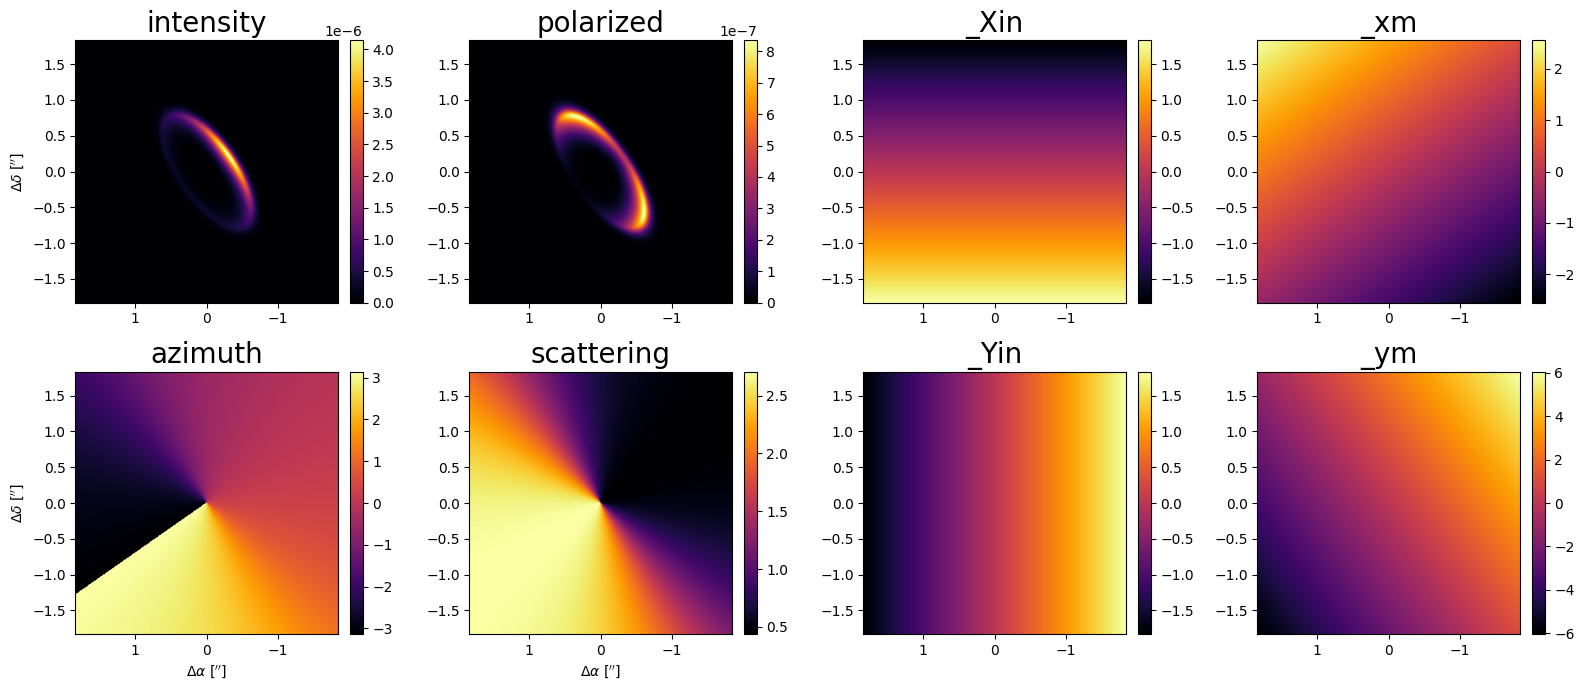

In [13]:
from DDiT import Disk
disk = Disk(**disk_params)

# Compute model parameters
model_params = {
    'a' : 0.95,             # Semi-major axis of the disk in arcseconds
    'incl' :65.,           # Inclination, in degrees
    'pa' : 145,            # Position angle, in degrees
    'pin' : 5.0,            # Inner slope of the density distribution (>0)
    'pout' : -15.0,         # Outer slope of the density distribution (<0)
    'e' : 0.0,              # Eccentricity
    'omega' : 85.,          # Argument of periapsis, in degrees
    'gsca' : 0.5,           # Henyey-Greenstein coefficient for total intensity
    'gpol' : 0.5,           # Henyey-Greenstein coefficient for polarized intensity
    'opang' : 0.03,         # Opening angle of the disk, in radians
    'wave' : 1200,          # Wavelength in units of microns.

}
disk.compute_model(**model_params)

fig, axs = plt.subplots(2, 4, figsize=(16, 7))
properties = ['intensity', 'polarized', "_Xin", "_xm", 'azimuth', 'scattering', "_Yin", "_ym"]
for ax, prop_name in zip(axs.ravel(), properties):
    data = getattr(disk, prop_name)
    # cax = ax.imshow(np.rot90(data, 2), extent=[disk._xlim, -disk._xlim, -disk._xlim, disk._xlim], cmap='inferno')
    cax = ax.imshow(data, extent=[disk._xlim, -disk._xlim, -disk._xlim, disk._xlim], cmap='inferno')
    cbar = fig.colorbar(cax, ax=ax, orientation='vertical', fraction=0.046, pad=0.04)
    ax.set_title(f'{prop_name}', fontsize=20)
    if prop_name in ['azimuth', 'scattering']:
        ax.set_xlabel('$\Delta \\alpha$ [$^{\prime\prime}$]')
    if prop_name in ['intensity', 'azimuth']:
        ax.set_ylabel('$\Delta \\delta$ [$^{\prime\prime}$]')

plt.tight_layout()
#plt.subplots_adjust(hspace=-0.15, wspace=0.2)  # Adjust the space between plots
#plt.savefig('output/images/{}_combined_plot.png'.format(dict_to_string(model_params)))
plt.show()

### Plot Q, U and theta

In [73]:
polarized_nan = disk.polarized.copy()
polarized_nan[polarized_nan == 0.0] = np.NaN

phi_polar = np.arctan2(disk._Yin,disk._Xin)
Q = -polarized_nan * np.cos(2*phi_polar)
U = -polarized_nan * np.sin(2*phi_polar)
theta = 0.5*np.arctan2(U, Q)

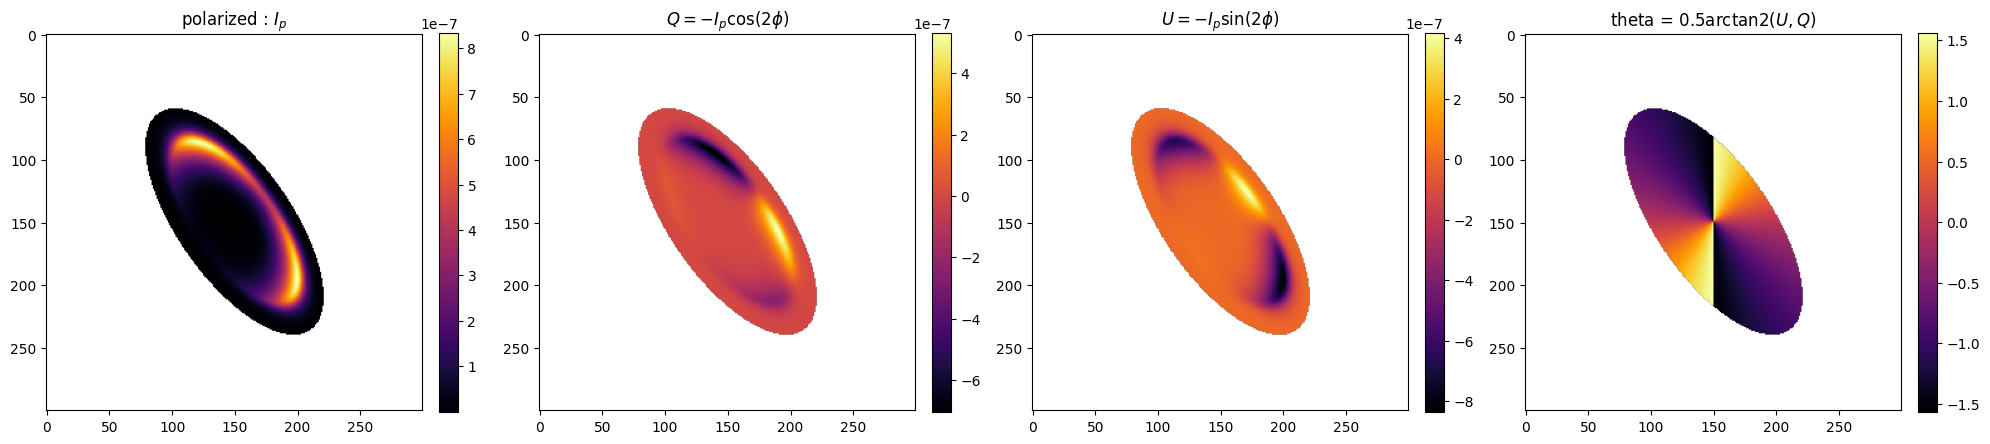

In [75]:
fig, axs = plt.subplots(1, 4, figsize=(20, 5))
# Plot polarized_nan
axs[0].imshow(polarized_nan, cmap='inferno')
axs[0].set_title('polarized : $I_p$')
fig.colorbar(axs[0].images[0], ax=axs[0], orientation='vertical', fraction=0.046, pad=0.04)

# Plot Q
axs[1].imshow(Q, cmap='inferno')
axs[1].set_title('$Q=-I_p\cos(2\phi)$')
fig.colorbar(axs[1].images[0], ax=axs[1], orientation='vertical', fraction=0.046, pad=0.04)

# Plot U
axs[2].imshow(U, cmap='inferno')
axs[2].set_title('$U=-I_p\sin(2\phi)$')
fig.colorbar(axs[2].images[0], ax=axs[2], orientation='vertical', fraction=0.046, pad=0.04)

# Plot theta
axs[3].imshow(theta, cmap='inferno')
axs[3].set_title('theta = $0.5$arctan2($U, Q$)')
fig.colorbar(axs[3].images[0], ax=axs[3], orientation='vertical', fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

### Generate and Save images

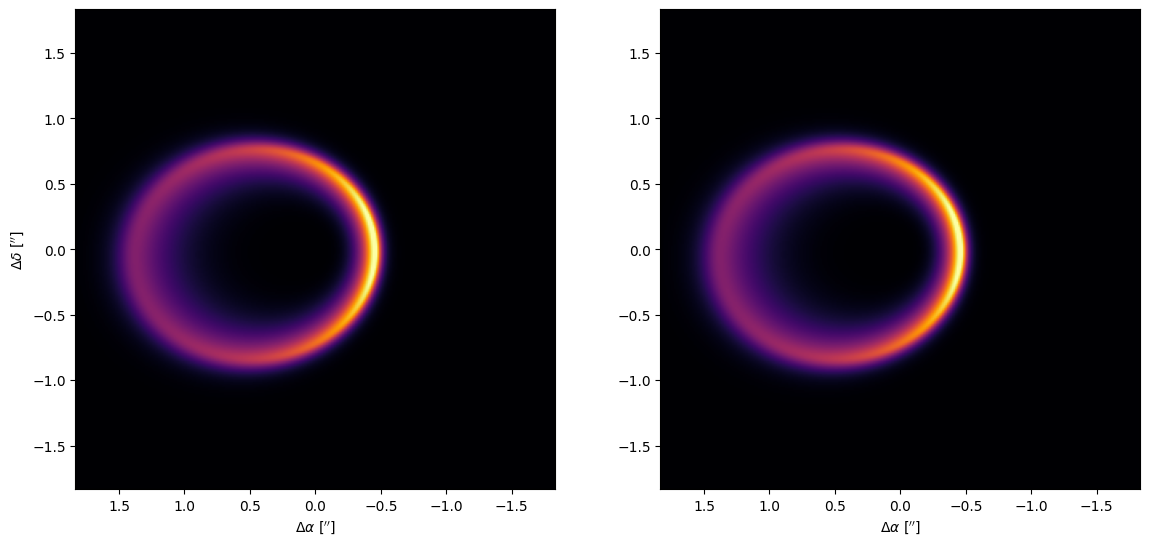

(300, 300)


In [37]:
from PIL import Image

# Compute model parameters
model_params = {
    'a' : 0.95,             # Semi-major axis of the disk in arcseconds
    'incl' : 0.,           # Inclination, in degrees
    'pa' : 0.,            # Position angle, in degrees
    'pin' : 5.0,            # Inner slope of the density distribution (>0)
    'pout' : -15.0,         # Outer slope of the density distribution (<0)
    'e' : 0.5,              # Eccentricity
    'omega' : 85.,          # Argument of periapsis, in degrees
    'gsca' : 0.5,           # Henyey-Greenstein coefficient for total intensity
    'gpol' : 0.5,           # Henyey-Greenstein coefficient for polarized intensity
    'opang' : 0.03,         # Opening angle of the disk, in radians
}
disk.compute_model(**model_params)
disk.plot()
print(disk.polarized.shape)

# Save the intensity image
intensity_image = Image.fromarray(normalized_data(disk.intensity).astype(np.uint8), 'L')
intensity_image.save('output/images/{}_intensity.bmp'.format(dict_to_string(model_params)))

# Save the polarized image
polarized_image = Image.fromarray(normalized_data(disk.polarized).astype(np.uint8), 'L')
polarized_image.save('output/images/{}_polarized.bmp'.format(dict_to_string(model_params)))

# Save the azimuth image
azimuth_image = Image.fromarray(normalized_data(disk.azimuth).astype(np.uint8), 'L')
azimuth_image.save('output/images/{}_azimuth.bmp'.format(dict_to_string(model_params)))

# Save the scattering image
scattering_image = Image.fromarray(normalized_data(disk.scattering).astype(np.uint8), 'L')
scattering_image.save('output/images/{}_scattering.bmp'.format(dict_to_string(model_params)))

In [77]:
# Create an RGB image using intensity, polarized, and azimuth data
rgb_image = np.zeros((disk.intensity.shape[0], disk.intensity.shape[1], 3), dtype=np.uint8)
rgb_image[..., 0] = normalized_data(disk.intensity).astype(np.uint8)  # Red channel
rgb_image[..., 1] = normalized_data(disk.polarized).astype(np.uint8)  # Green channel
rgb_image[..., 2] = normalized_data(disk.scattering).astype(np.uint8)    # Blue channel

# Save the RGB image
rgb_image_pil = Image.fromarray(rgb_image, 'RGB')
rgb_image_pil.save('output/images_rgb/{}_rgb.bmp'.format(dict_to_string(model_params)))

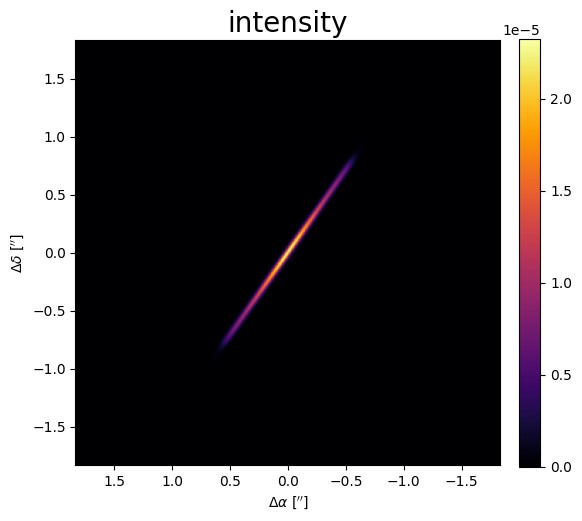

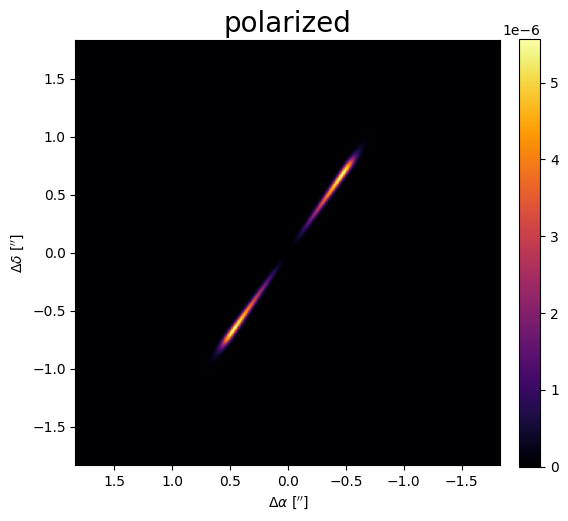

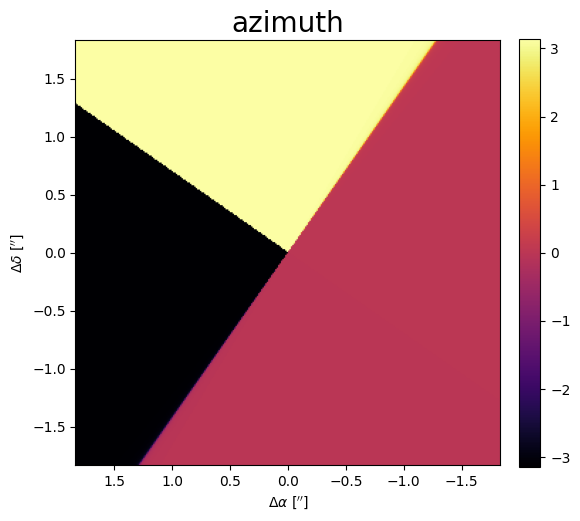

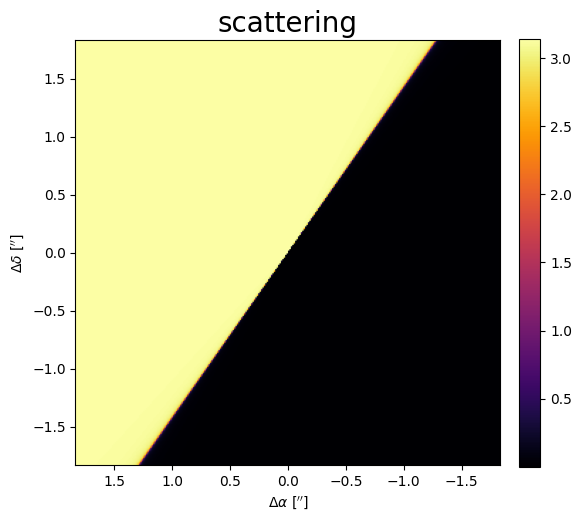

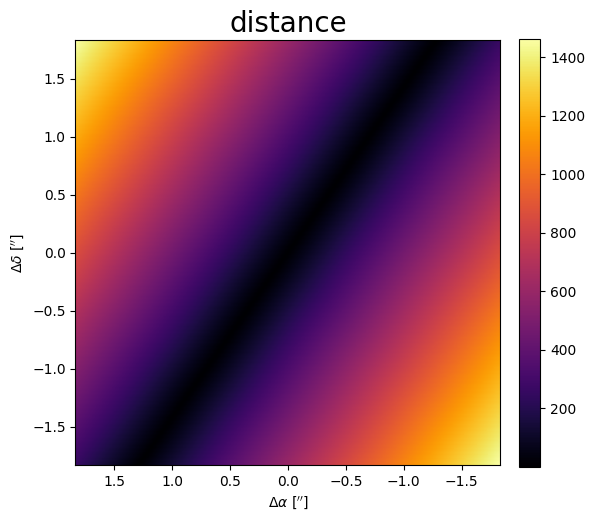

In [78]:
def plot_and_save(disk, model_params, prop_name):
    data = getattr(disk, prop_name)
    fig, ax = plt.subplots(figsize=(6, 6))
    cax = ax.imshow(data, origin='lower', extent=[disk._xlim, -disk._xlim, -disk._xlim, disk._xlim], cmap='inferno', vmin=np.min(data), vmax=np.max(data))
    cbar = fig.colorbar(cax, ax=ax, orientation='vertical', fraction=0.046, pad=0.04)
    ax.set_xlabel('$\Delta \\alpha$ [$^{\prime\prime}$]')
    ax.set_ylabel('$\Delta \delta$ [$^{\prime\prime}$]')
    plt.title(f'{prop_name}', fontsize=20)
    plt.savefig('output/images/{}_{}_plot.png'.format(dict_to_string(model_params), prop_name))
    plt.show()
    
plot_and_save(disk, model_params, 'intensity')
plot_and_save(disk, model_params, 'polarized')
plot_and_save(disk, model_params, 'azimuth')
plot_and_save(disk, model_params, 'scattering')
plot_and_save(disk, model_params, 'distance')

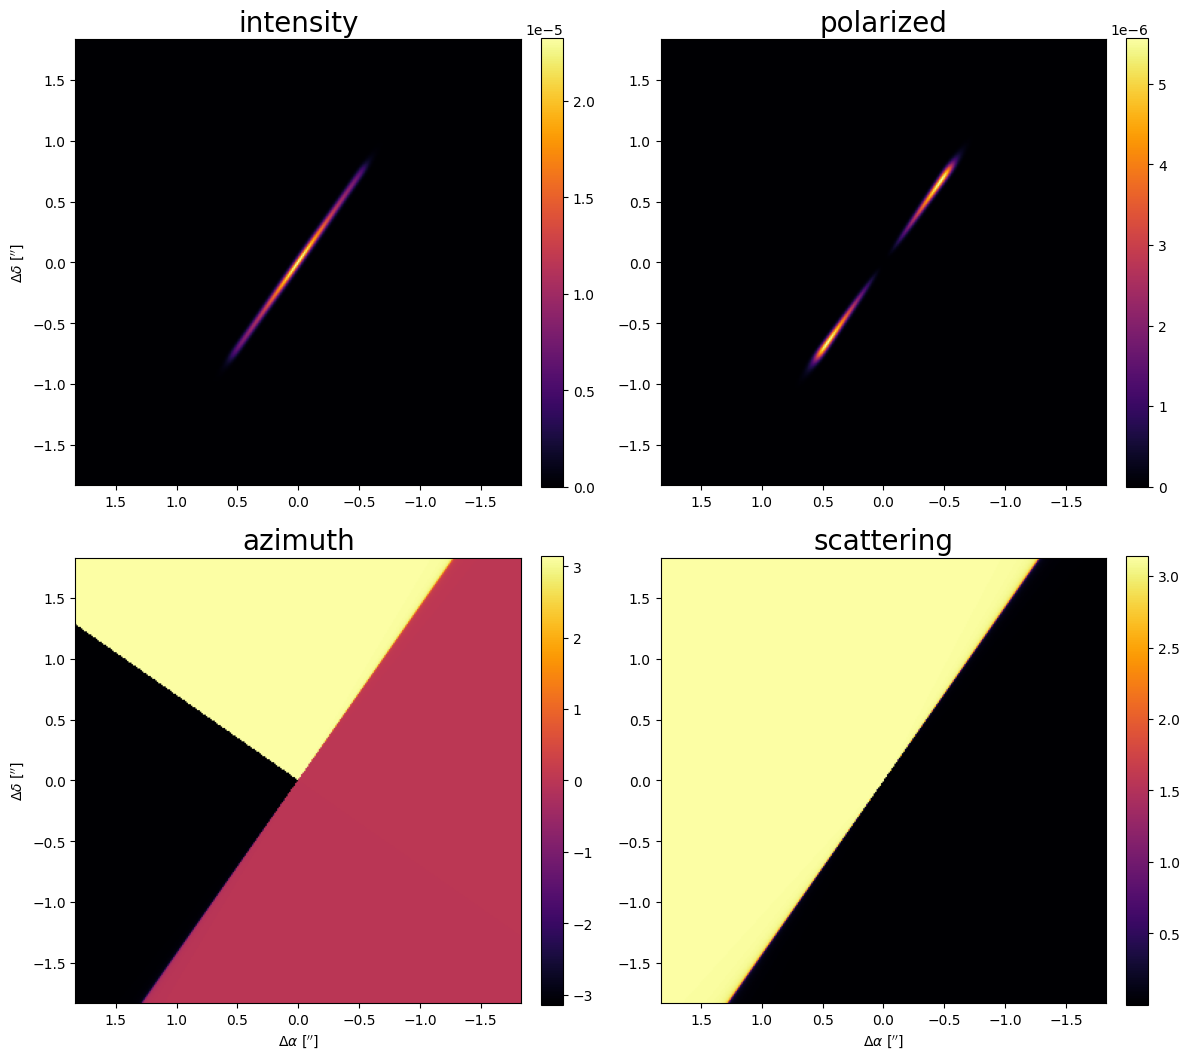

In [79]:
fig, axs = plt.subplots(2, 2, figsize=(12, 12))

properties = ['intensity', 'polarized', 'azimuth', 'scattering']
for ax, prop_name in zip(axs.ravel(), properties):
    data = getattr(disk, prop_name)
    cax = ax.imshow(data, origin='lower', extent=[disk._xlim, -disk._xlim, -disk._xlim, disk._xlim], cmap='inferno', vmin=np.min(data), vmax=np.max(data))
    cbar = fig.colorbar(cax, ax=ax, orientation='vertical', fraction=0.046, pad=0.04)
    ax.set_title(f'{prop_name}', fontsize=20)
    if prop_name in ['azimuth', 'scattering']:
        ax.set_xlabel('$\Delta \\alpha$ [$^{\prime\prime}$]')
    if prop_name in ['intensity', 'azimuth']:
        ax.set_ylabel('$\Delta \\delta$ [$^{\prime\prime}$]')

plt.tight_layout()
plt.subplots_adjust(hspace=-0.15, wspace=0.2)  # Adjust the space between plots
plt.savefig('output/images/{}_combined_plot.png'.format(dict_to_string(model_params)))
plt.show()

# Comparaison params influence

In [92]:
# Compute model parameters
model_params = {
    'a' : np.array([0.95, 1.5]),             # Semi-major axis of the disk in arcseconds
    'incl' : [60., 110.],           # Inclination, in degrees
    'pa' : 112.,            # Position angle, in degrees
    'pin' : 5.0,            # Inner slope of the density distribution (>0)
    'pout' : -15.0,         # Outer slope of the density distribution (<0)
    'e' : 0.1,              # Eccentricity
    'omega' : 85.,          # Argument of periapsis, in degrees
    'gsca' : 0.5,           # Henyey-Greenstein coefficient for total intensity
    'gpol' : 0.5,           # Henyey-Greenstein coefficient for polarized intensity
    'opang' : 0.03,         # Opening angle of the disk, in radians
}

In [93]:
def recursive_compute_model(params, input_disk):
    for key, value in params.items():
        # If list in the 
        if isinstance(value, list) or isinstance(value, np.ndarray):
            for v in value:
                temp_params = params.copy()
                temp_params[key] = v
                recursive_compute_model(temp_params, input_disk)
            return
    print("a : {}, incl : {}".format(params['a'], params['incl']))
    input_disk.compute_model(**params)
    input_disk.plot()

a : 0.95, incl : 60.0


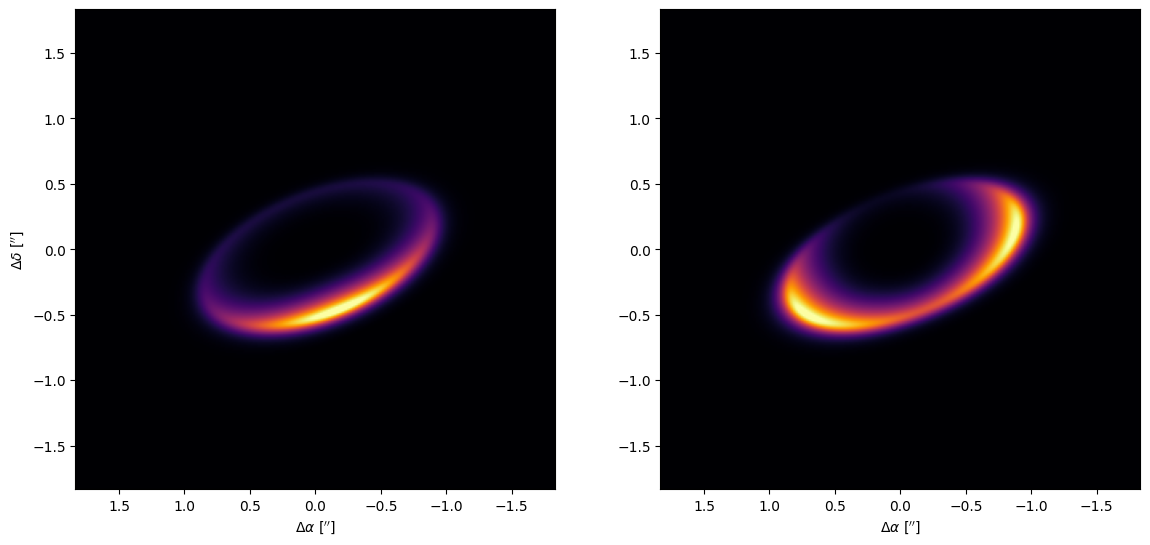

a : 0.95, incl : 110.0


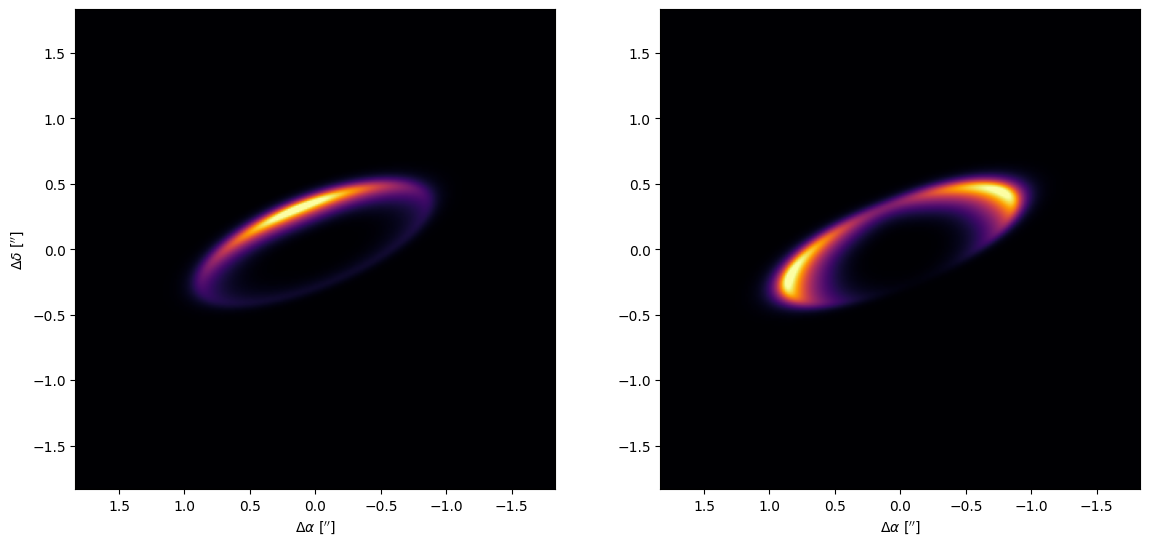

a : 1.5, incl : 60.0


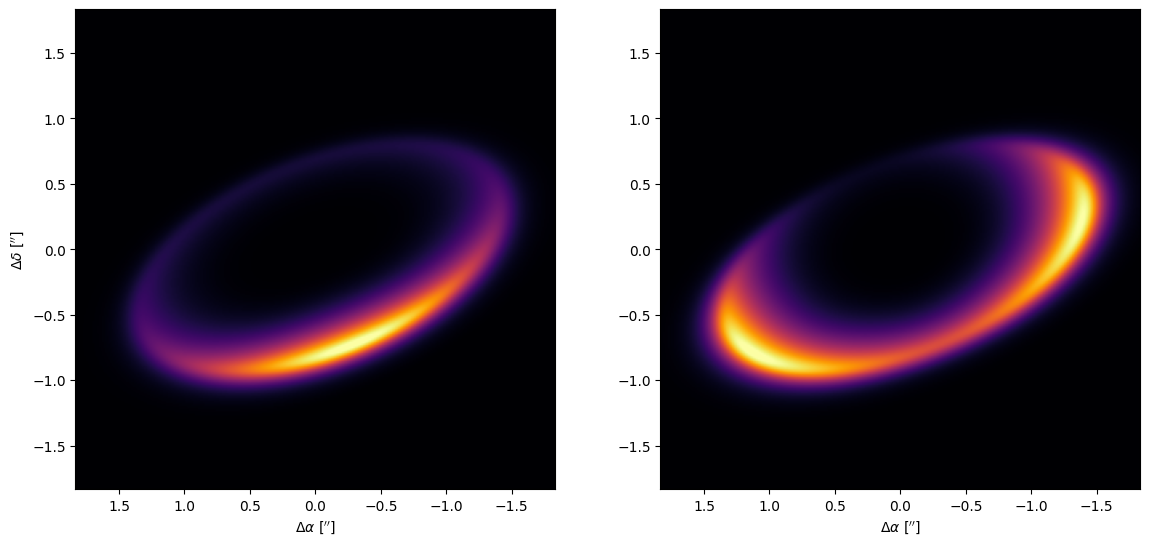

a : 1.5, incl : 110.0


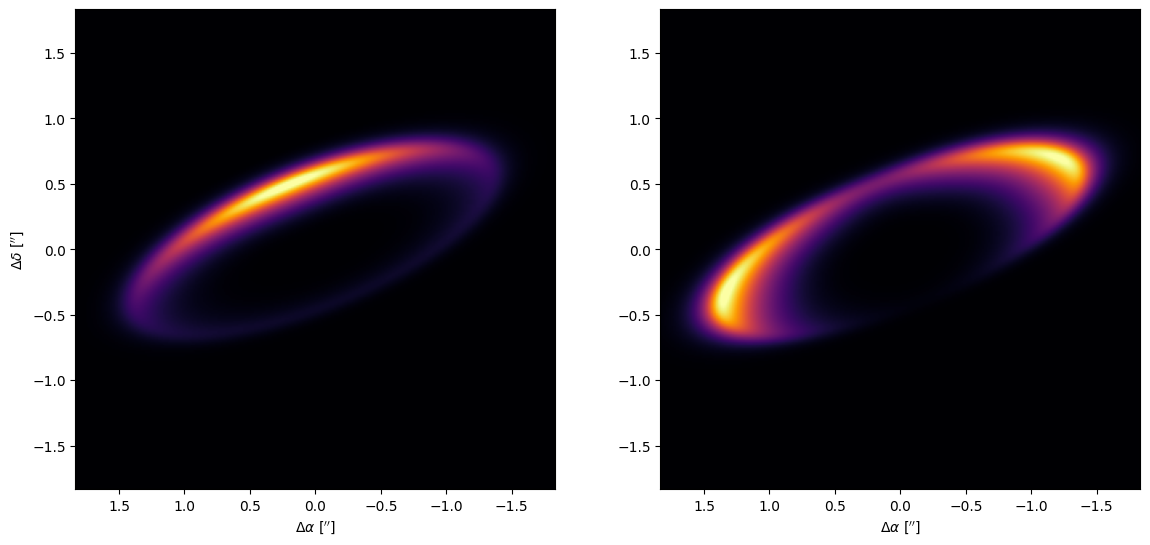

In [94]:
recursive_compute_model(model_params, disk)

# HDF5 Dataset Generation

## Function Save HDF5 

In [5]:
def save_to_hdf5(filename, disk_data, disk_theta, labels):
    with h5py.File(filename, "w") as f:
        # Création des datasets avec compression
        dset = f.create_dataset("disk_data", data=disk_data, compression="gzip")
        f.create_dataset("disk_theta", data=disk_theta, compression="gzip")
        f.create_dataset("labels", data=labels, compression="gzip")

        # Ajout des métadonnées en tant qu'attributs
        dset.attrs["description"] = (
            "Disks dataset (Total Intensity, Polarized) d'images 300x300 avec 4 méta-données : (a, incl, pa, e)"
        )
        dset.attrs["param_names"] = ["a", "incl", "pa", "e"]

## Dataset computation

### Inputs

In [5]:
# The parameters values
NB_PARAMS = 4
a = np.linspace(0.2, 1.0, 10)
incl = np.linspace(0, 90, 10)
pa = np.linspace(0, 180, 10)
e = np.linspace(0, 0.6,10)
# wave = np.array([900, 1200, 1600, 2200])

NB_SAMPLE = len(a) * len(incl) * len(pa) * len(e)
if NB_SAMPLE > 100000:
    raise ValueError("The number of loops is too large: {}. Needs to code multiple files creation".format(NB_SAMPLE))
print("Number of samples: {}".format(NB_SAMPLE))

# Create the data arrays (500, 2, 300, 300)
disk_data = np.zeros((NB_SAMPLE, 2, disk_params["nx"], disk_params["nx"]), dtype=np.float64)  # all disks data
disk_theta = np.zeros((disk_params["nx"], disk_params["nx"]), dtype=np.float64)  # all disks data
labels = np.zeros((NB_SAMPLE, NB_PARAMS), dtype=np.float64)  # 4 valeurs par triplet

disk = Disk(**disk_params)
disk_theta = compute_theta(disk)


Number of samples: 10000


### Sans parallélisation

In [ ]:
i_loop = 0
presentime = datetime.now()

# Initialize the tqdm progress bar
progress_bar = tqdm(total=NB_SAMPLE, desc="Images created")

# Main loop 
for val_a in a:
    disk.a = val_a
    for val_incl in incl:
        disk.incl = val_incl
        for val_pa in pa:
            disk.pa = val_pa
            for val_e in e:
                disk.e = val_e

                # Calcul du modèle
                disk.compute_model()

                # Stockage des données
                disk_data[i_loop, 0] = disk.intensity
                disk_data[i_loop, 1] = disk.polarized

                # Sauvegarde des paramètres
                labels[i_loop] = np.array([val_a, val_incl, val_pa, val_e])

                i_loop += 1
                progress_bar.update(1)  # Update the progress bar

progress_bar.close()  # Close the progress bar when done

# Save the data to an HDF5 file
save_to_hdf5("output/dataset_DDiT.h5", disk_data, disk_theta, labels)


### Avec parallélisation

In [ ]:
from multiprocessing import Pool, cpu_count

def process_disk(params):
    val_a, val_incl, val_pa, val_e, disk_params = params
    disk = Disk(**disk_params)
    disk.a = val_a
    disk.incl = val_incl
    disk.pa = val_pa
    disk.e = val_e
    disk.compute_model()
    intensity = disk.intensity
    polarized = disk.polarized
    label = np.array([val_a, val_incl, val_pa, val_e])
    return intensity, polarized, label

# Prepare the parameters for parallel processing
params_list = [(val_a, val_incl, val_pa, val_e, disk_params) for val_a in a for val_incl in incl for val_pa in pa for val_e in e]

# Use multiprocessing to parallelize the computation
with Pool(cpu_count()) as pool:
    results = list(tqdm(pool.imap(process_disk, params_list), total=NB_SAMPLE, desc="Images created"))

# Collect the results
for i, (intensity, polarized, label) in enumerate(results):
    disk_data[i, 0] = intensity
    disk_data[i, 1] = polarized
    labels[i] = label

# Save the data to an HDF5 file
print("Saving data to HDF5 file...")
save_to_hdf5("output/dataset_DDiT.h5", disk_data, disk_theta, labels)

## Multi files...

In [90]:
def initialize_disk(disk_params):
    """Initialise l'objet Disk et calcule disk_theta une seule fois."""
    disk = Disk(**disk_params)
    disk_theta = compute_theta(disk)
    return disk, disk_theta

def save_batch(file_idx, disk_data, disk_theta, labels, batch_size):
    """Sauvegarde un batch de données dans un fichier HDF5."""
    filename = f"output/dataset_DDiT_{file_idx}.h5"
    save_to_hdf5(filename, disk_data[:batch_size], disk_theta, labels[:batch_size])
    print(f"📂 Sauvegarde du fichier {filename} ({batch_size} échantillons)")

def process_sample(disk, val_a, val_incl, val_pa, val_e):
    """Met à jour les paramètres du disque, calcule le modèle et retourne les données."""
    disk.a = val_a
    disk.incl = val_incl
    disk.pa = val_pa
    disk.e = val_e
    disk.compute_model()
    
    return disk.intensity, disk.polarized, np.array([val_a, val_incl, val_pa, val_e])

def generate_dataset(a, incl, pa, e, disk_params, chunk_size=50):
    """Génère et sauvegarde un dataset en plusieurs fichiers HDF5 si nécessaire."""
    
    NB_SAMPLE = len(a) * len(incl) * len(pa) * len(e)

    disk, disk_theta = initialize_disk(disk_params)

    # Initialisation de tqdm
    progress_bar = tqdm(total=NB_SAMPLE, desc="Images created", dynamic_ncols=True)

    # Variables de gestion
    file_idx, i_loop, batch_idx = 1, 0, 0

    # Allocation mémoire pour un batch
    disk_data = np.zeros((chunk_size, 2, disk_params["nx"], disk_params["nx"]), dtype=np.float64)
    labels = np.zeros((chunk_size, 4), dtype=np.float64)  # 4 paramètres : (a, incl, pa, e)

    # Boucle principale
    for val_a in a:
        for val_incl in incl:
            for val_pa in pa:
                for val_e in e:
                    intensity, polarized, label = process_sample(disk, val_a, val_incl, val_pa, val_e)

                    # Stockage des données
                    disk_data[batch_idx, 0] = intensity
                    disk_data[batch_idx, 1] = polarized
                    labels[batch_idx] = label

                    i_loop += 1
                    batch_idx += 1
                    progress_bar.update(1)

                    # Sauvegarde et reset du batch si nécessaire
                    if batch_idx == chunk_size or i_loop == NB_SAMPLE:
                        save_batch(file_idx, disk_data, disk_theta, labels, batch_idx)
                        batch_idx = 0
                        file_idx += 1

    progress_bar.close()
    print(f"✅ {i_loop} échantillons traités et sauvegardés en {file_idx-1} fichiers HDF5.")


In [91]:
# Appel de la fonction principale
generate_dataset(a, incl, pa, e, disk_params, chunk_size=50)

Images created:  62%|██████▏   | 50/81 [00:32<00:14,  2.08it/s]

📂 Sauvegarde du fichier output/dataset_DDiT_1.h5 (50 échantillons)


Images created: 100%|██████████| 81/81 [00:57<00:00,  1.42it/s]

📂 Sauvegarde du fichier output/dataset_DDiT_2.h5 (31 échantillons)
✅ 81 échantillons traités et sauvegardés en 2 fichiers HDF5.


## Visualisation

### Reading HDF5

In [6]:
with h5py.File("output/dataset_DDiT.h5", "r") as f:
    disk_data = f["disk_data"][:]       # Lire tout le dataset
    disk_theta = f["disk_theta"][:]       # Lire le disk_theta
    labels = f["labels"][:]         # Méta-données associées
    description = f["disk_data"].attrs["description"]
    param_names = f["disk_data"].attrs["param_names"]
    
print("Disk chargé :", disk_data.shape)
print("Disk theta chargé :", disk_theta.shape)
print("labels associées :", labels.shape)
print("description :", description)
print("param_names :", param_names)

Disk chargé : (10000, 2, 300, 300)
Disk theta chargé : (10000, 2, 300, 300)
labels associées : (10000, 4)
description : Disks dataset (Total Intensity, Polarized) d'images 300x300 avec 4 méta-données : (a, incl, pa, e)
param_names : ['a' 'incl' 'pa' 'e']


### Plotting HDF5

a=0.37777777777777777, incl=30.0, pa=20.0, e=0.06666666666666667, 

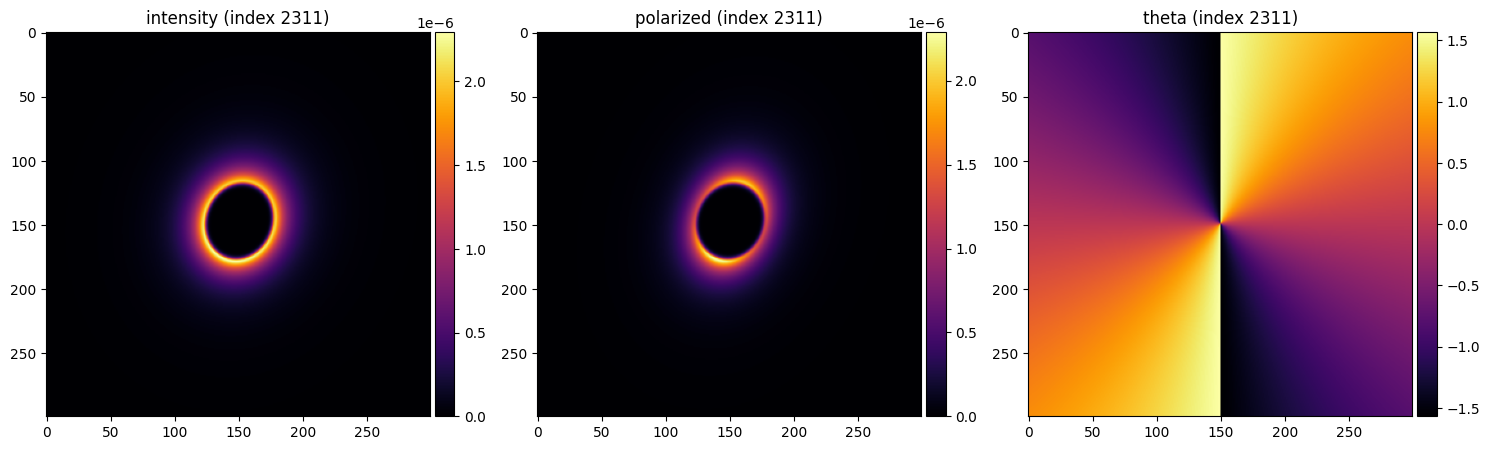

a=0.7333333333333334, incl=80.0, pa=80.0, e=0.0, 

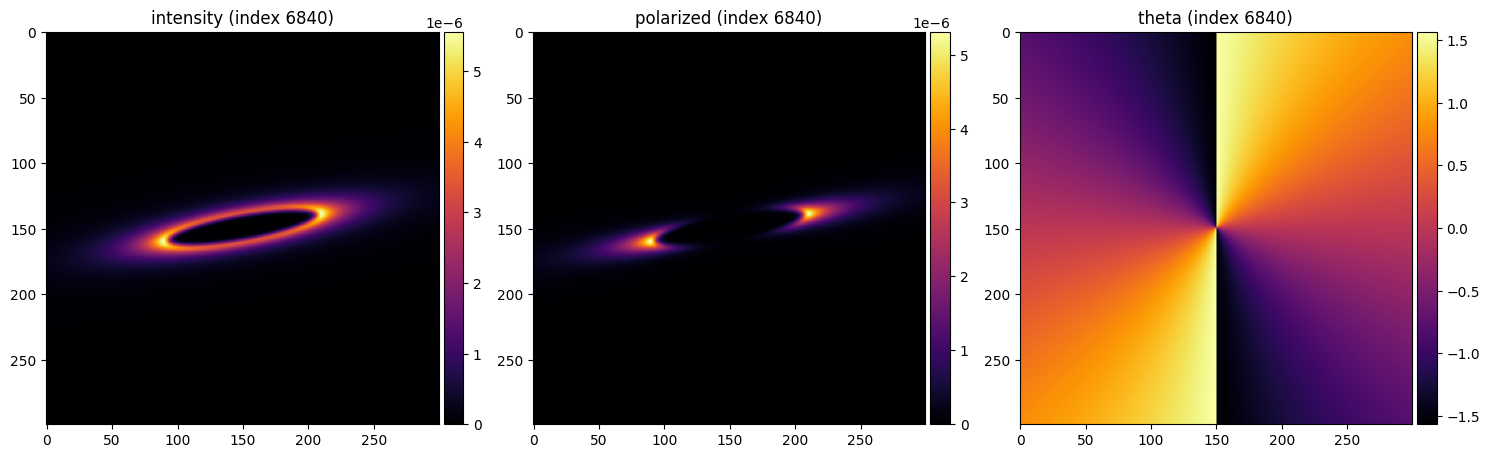

a=0.5555555555555556, incl=40.0, pa=0.0, e=0.06666666666666667, 

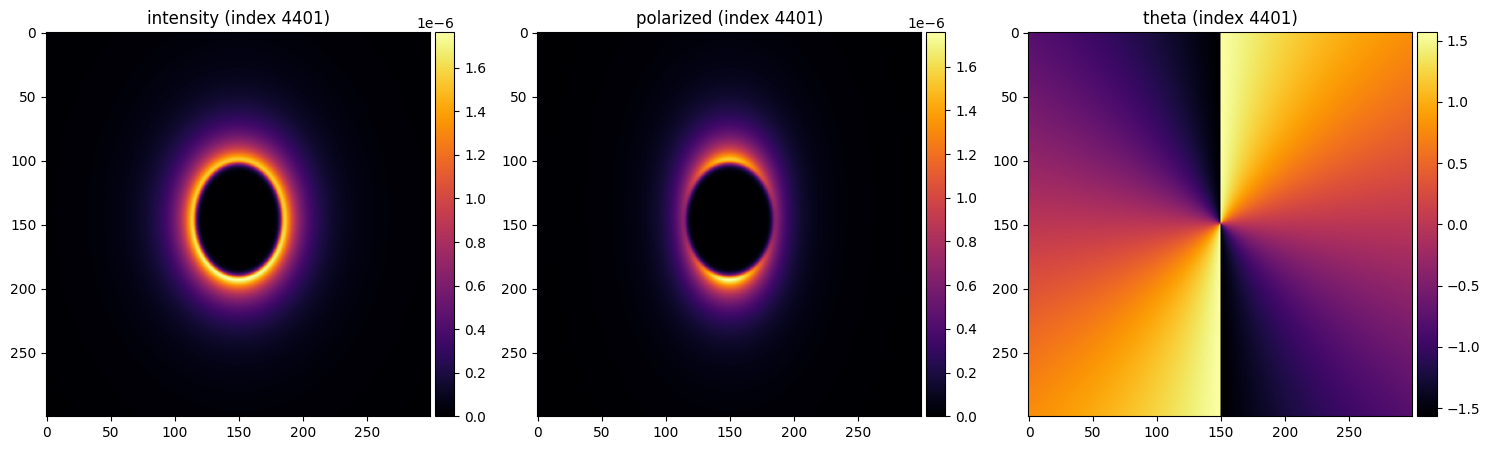

In [10]:
for i in range(3):

    # Sélectionner un indice aléatoire
    random_index = random.randint(0, data.shape[0] - 1)

    # dsds
    for i, name in enumerate(param_names):
        print(f"{name}={labels[random_index, i]}, ", end='')

    #
    fig, axs = plt.subplots(1, 3, figsize=(15, 5))

    # Noms des propriétés à afficher
    properties = ['intensity', 'polarized', 'theta']

    # Afficher les images
    for ax, prop_name in zip(axs, properties):
        data_index = properties.index(prop_name)
        if prop_name == 'theta':
            im = ax.imshow(disk_theta, cmap='inferno')
        else:
            im = ax.imshow(data[random_index, data_index], cmap='inferno')
        ax.set_title(f'{prop_name} (index {random_index})')
        #ax.axis('off')
        
        # Ajouter une colorbar
        divider = make_axes_locatable(ax)
        cax = divider.append_axes("right", size="5%", pad=0.05)
        plt.colorbar(im, cax=cax)

    plt.tight_layout()
    plt.show()

# Testing if wave got an impact

In [14]:
previous_intensity = np.zeros((300,300))
previous_polarized = np.zeros((300,300))
wavelength = np.array([900,1200, 1600, 2200])

for i, wave in enumerate(wavelength):

    # Compute model parameters
    model_params = {
        'a' : 0.95,             # Semi-major axis of the disk in arcseconds
        'incl' :75.,            # Inclination, in degrees
        'pa' : 145,             # Position angle, in degrees
        'pin' : 5.0,            # Inner slope of the density distribution (>0)
        'pout' : -15.0,         # Outer slope of the density distribution (<0)
        'e' : 0.0,              # Eccentricity
        'omega' : 85.,          # Argument of periapsis, in degrees
        'gsca' : 0.5,           # Henyey-Greenstein coefficient for total intensity
        'gpol' : 0.5,           # Henyey-Greenstein coefficient for polarized intensity
        'opang' : 0.03,         # Opening angle of the disk, in radians
        'wave' : wave,          # Wavelength in units of microns.
    }
    disk.compute_model(**model_params)

    # Printing diff to see the impact 
    if i != 0:
        intensity_norm_changes = np.linalg.norm(disk.intensity - previous_intensity)
        polarized_norm_changes = np.linalg.norm(disk.polarized - previous_polarized)

        print(f"#{i} wavelength comparaison: ({wavelength[i-1]},{wavelength[i]})")
        print(f"diff_intensity= {intensity_norm_changes}")
        print(f"diff_polarized= {polarized_norm_changes}\n")

    previous_intensity = disk.intensity
    previous_polarized = disk.polarized

#1 wavelength comparaison: (900,1200)
diff_intensity= 0.0
diff_polarized= 0.0

#2 wavelength comparaison: (1200,1600)
diff_intensity= 0.0
diff_polarized= 0.0

#3 wavelength comparaison: (1600,2200)
diff_intensity= 0.0
diff_polarized= 0.0



In [10]:
previous_intensity = np.zeros((300,300))
previous_polarized = np.zeros((300,300))
incl = np.linspace(0,90,3)

for i, inc in enumerate(incl):

    # Compute model parameters
    model_params = {
        'a' : 0.95,             # Semi-major axis of the disk in arcseconds
        'incl' :inc,            # Inclination, in degrees
        'pa' : 145,             # Position angle, in degrees
        'pin' : 5.0,            # Inner slope of the density distribution (>0)
        'pout' : -15.0,         # Outer slope of the density distribution (<0)
        'e' : 0.0,              # Eccentricity
        'omega' : 85.,          # Argument of periapsis, in degrees
        'gsca' : 0.5,           # Henyey-Greenstein coefficient for total intensity
        'gpol' : 0.5,           # Henyey-Greenstein coefficient for polarized intensity
        'opang' : 0.03,         # Opening angle of the disk, in radians
        'wave' : 900,          # Wavelength in units of microns.
    }
    disk.compute_model(**model_params)

    # Printing diff to see the impact 
    if i != 0:
        intensity_norm_changes = np.linalg.norm(disk.intensity - previous_intensity)
        polarized_norm_changes = np.linalg.norm(disk.polarized - previous_polarized)

        print(f"#{i} incl comparaison: ({incl[i-1]},{incl[i]})")
        print(f"diff_intensity= {intensity_norm_changes}")
        print(f"diff_polarized= {polarized_norm_changes}\n")

    previous_intensity = disk.intensity
    previous_polarized = disk.polarized

#1 incl comparaison: (0.0,45.0)
diff_intensity= 4.159748076880934e-05
diff_polarized= 2.2007525940835118e-05

#2 incl comparaison: (45.0,90.0)
diff_intensity= 0.0002933777900336339
diff_polarized= 7.120614991024812e-05

